In [77]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [78]:
#imporing data

df = pd.read_csv('../Data_sets/insurance.csv')
df.head()

,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520


In [79]:
#getting data set info

print("Shape :",df.shape)
print(f"Number of Traing data sets: {df.shape[0]} | Number of features: {df.shape[1]}")
print("----"*20)

print(df.info())    
print("----"*20)
print(df.isnull().sum())  

Shape : (1338, 7)
Number of Traing data sets: 1338 | Number of features: 7
--------------------------------------------------------------------------------
<class 'pandas.DataFrame'>
RangeIndex: 1338 entries, 0 to 1337
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1338 non-null   int64  
 1   sex       1338 non-null   str    
 2   bmi       1338 non-null   float64
 3   children  1338 non-null   int64  
 4   smoker    1338 non-null   str    
 5   region    1338 non-null   str    
 6   charges   1338 non-null   float64
dtypes: float64(2), int64(2), str(3)
memory usage: 73.3 KB
None
--------------------------------------------------------------------------------
age         0
sex         0
bmi         0
children    0
smoker      0
region      0
charges     0
dtype: int64


In [80]:

#Binary encoding
df['sex'] = df['sex'].map({'male':0, 'female':1})
df['smoker'] = df['smoker'].map({'no': 0,  'yes': 1})

#one-hot encoding for region (Droping first to avoid dummy trap)

region_dummies = pd.get_dummies(df['region'], prefix='region', drop_first=True).astype(int)
df = pd.concat([df, region_dummies], axis=1)
df.drop('region', axis=1, inplace=True)

# 4. Reorder columns: features first, target last
feature_cols = ['age', 'sex', 'bmi', 'children', 'smoker', 
                'region_northwest', 'region_southeast', 'region_southwest']
df = df[feature_cols + ['charges']]

# Convert charges to 100-dollar scale
df['charges'] = df['charges'] / 100

#checking the encoded dataset
df.head()

,age,sex,bmi,children,smoker,region_northwest,region_southeast,region_southwest,charges
0,19,1,27.900,0,1,0,0,1,168.849240
1,18,0,33.770,1,0,0,1,0,17.255523
2,28,0,33.000,3,0,0,1,0,44.494620
3,33,0,22.705,0,0,1,0,0,219.844706
4,32,0,28.880,0,0,1,0,0,38.668552


In [81]:
from sklearn.preprocessing import StandardScaler

#Feature matrix and target vetcor

x_feature = df.drop('charges',axis=1).values
y_target = df['charges'].values.reshape(-1,1)

#Scaling the values 
scaler = StandardScaler()
x_scaled = scaler.fit_transform(x_feature)

#Adding intercept coloumns (ones) in Normalized scaled feature matrix 
X = np.c_[np.ones(x_scaled.shape[0]), x_scaled]
y = scaler.fit_transform(y_target)


#printing the shape
print(f"Shape of Feature matrix: {X.shape}")
print(f"Shape of taget vector: {y.shape}")


Shape of Feature matrix: (1338, 9)
Shape of taget vector: (1338, 1)


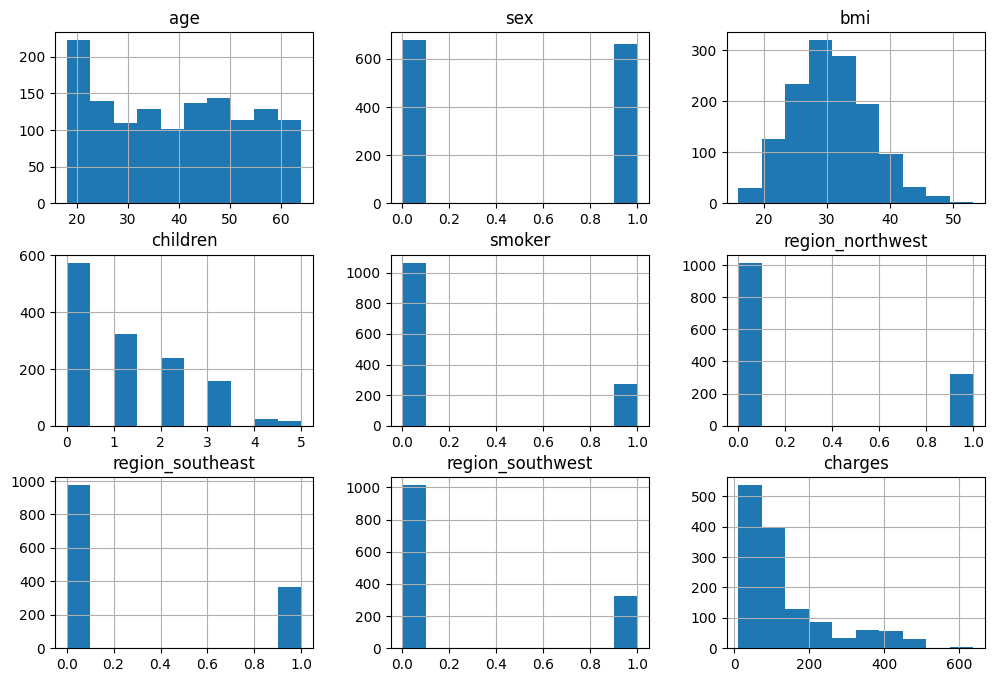

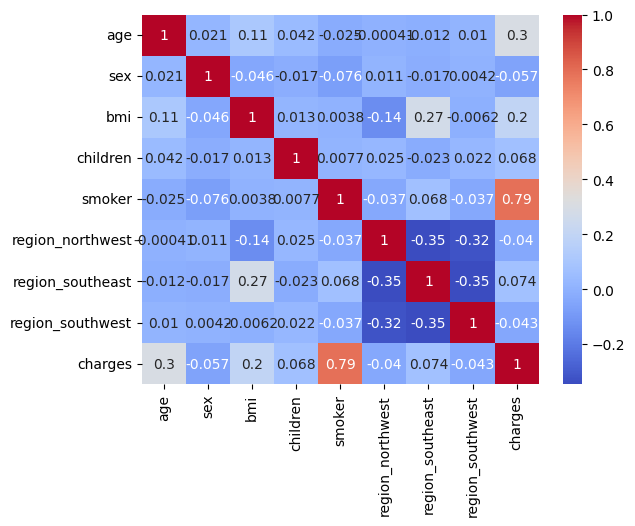

In [82]:


# 1. Distribution check
df.hist(figsize=(12, 8))
plt.show()

# 2. Correlation matrix (STANDARD)
sns.heatmap(df.corr(), annot=True, cmap='coolwarm')
plt.show()



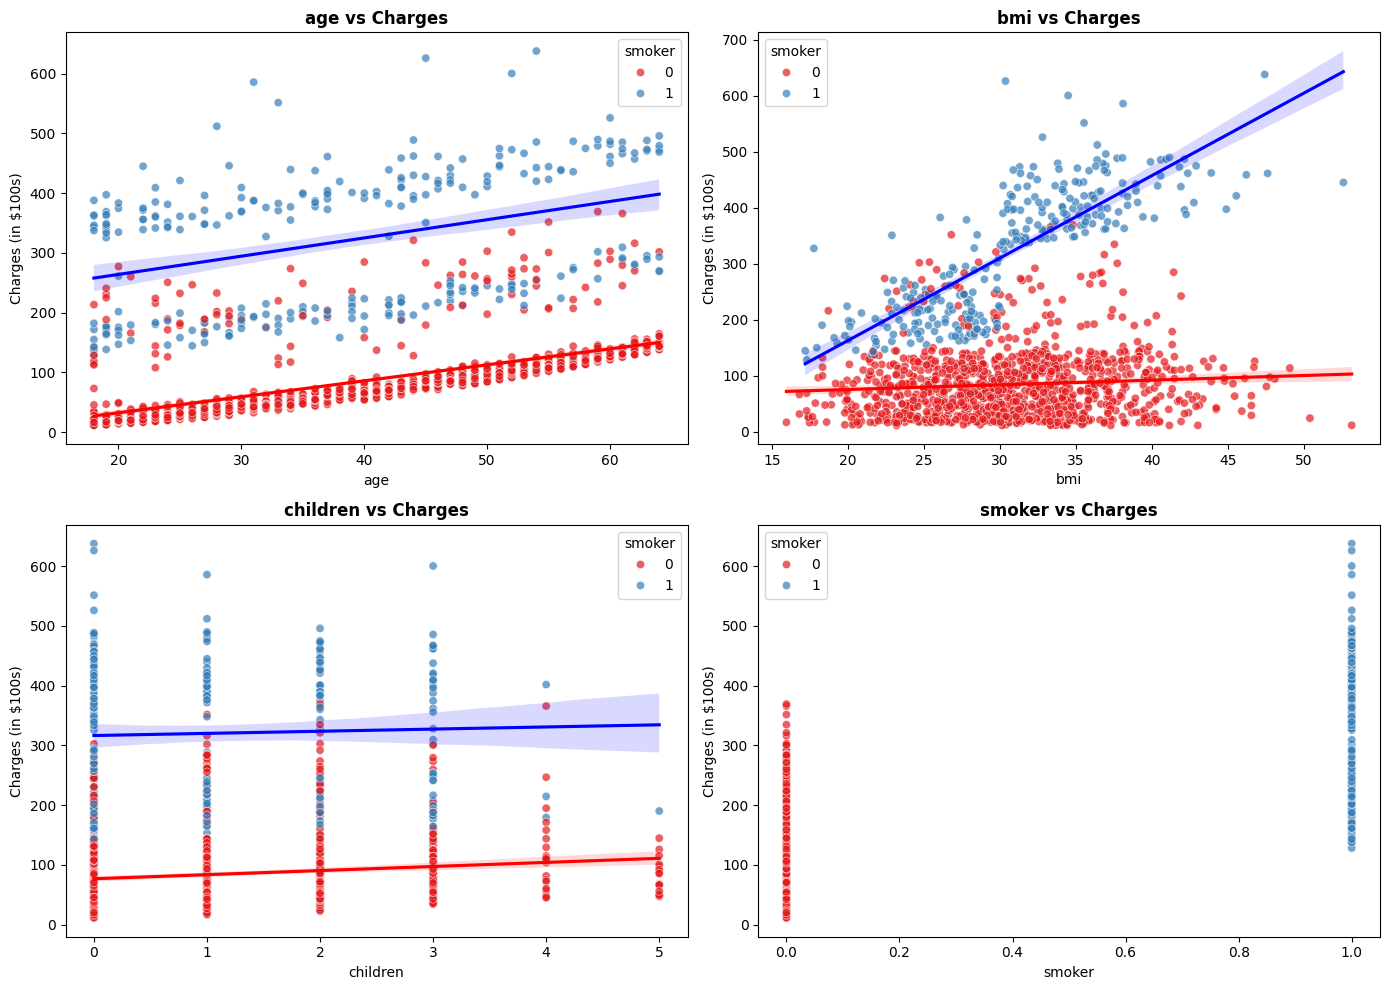

In [87]:

# Create subplots
selected_features = ['age', 'bmi', 'children', 'smoker']
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.ravel()  # Flatten to 1D for easier iteration

for idx, col in enumerate(selected_features):
    sns.scatterplot(data=df, x=col, y='charges', hue='smoker', 
                    alpha=0.7, ax=axes[idx], palette='Set1')
    
    # Add trend lines for each group
    sns.regplot(data=df[df['smoker']==0], x=col, y='charges', 
                scatter=False, color='red', ax=axes[idx], label='Non-smoker trend')
    
    sns.regplot(data=df[df['smoker']==1], x=col, y='charges', 
                scatter=False, color='blue', ax=axes[idx], label='Smoker trend')
    
    axes[idx].set_title(f'{col} vs Charges', fontsize=12, fontweight='bold')
    axes[idx].set_ylabel('Charges (in $100s)')

plt.tight_layout()
plt.show()    

